# Task 3: LSTM Time Series Forecasting for Tesla (TSLA)

**Project:** Portfolio Management Optimization for GMF Investments  
**Author:** Senior Deep Learning Engineer  
**Date:** January 2026

---

## 🧠 Objective

Build a Deep Learning-based time series forecasting model using **Long Short-Term Memory (LSTM)** networks to predict Tesla (TSLA) stock prices. This approach models non-linear dependencies and long-term patterns that traditional statistical models (like ARIMA) might miss.

### Deliverables:
1. Data normalization and sequence generation (sliding window)
2. LSTM model architecture design and training
3. Forecasting with inverse transformation
4. Performance evaluation (MAE, RMSE, MAPE)
5. Comparison with ARIMA baseline

### Data Split (Consistent with Task 2):
- **Training:** 2015-01-01 to 2024-12-31
- **Testing:** 2025-01-01 to 2026-01-15

---

## 📦 Setup and Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Data extraction
import yfinance as yf

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ Libraries imported successfully")
print(f"   TensorFlow Version: {tf.__version__}")

✅ Libraries imported successfully
   TensorFlow Version: 2.20.0


---

## 📊 STEP 1: Data Loading and Preparation

We use the same data source and split as the ARIMA task to ensure fair comparison.

**Key Steps:**
1. Download TSLA historical data
2. Extract Adjusted Close prices
3. Apply MinMax Scaling (0-1 range)
4. create sequences

In [2]:
# Download Tesla stock data
print("Downloading TSLA data...")
# We download extra data to handle the lookback window for the test set start
tsla_raw = yf.download('TSLA', start='2014-10-01', end='2026-01-28', progress=False)

# Extract the closing price
# Logic to handle different yfinance return formats (MultiIndex vs Single Index)
if isinstance(tsla_raw.columns, pd.MultiIndex):
    if 'Adj Close' in tsla_raw.columns.get_level_values(0):
        tsla_prices = tsla_raw[('Adj Close', 'TSLA')].dropna()
    elif 'Close' in tsla_raw.columns.get_level_values(0):
        print("Note: 'Adj Close' not found, using 'Close' price.")
        tsla_prices = tsla_raw[('Close', 'TSLA')].dropna()
    else:
        tsla_prices = tsla_raw.iloc[:, -1].dropna()
else:
    if 'Adj Close' in tsla_raw.columns:
        tsla_prices = tsla_raw['Adj Close'].dropna()
    elif 'Close' in tsla_raw.columns:
        print("Note: 'Adj Close' not found, using 'Close' price.")
        tsla_prices = tsla_raw['Close'].dropna()
    else:
        tsla_prices = tsla_raw.iloc[:, -1].dropna()

# Ensure it's a Series
if isinstance(tsla_prices, pd.DataFrame):
    tsla_prices = tsla_prices.squeeze()

# Filter to our exact analysis period starts
full_data = tsla_prices[tsla_prices.index >= '2015-01-01']

print(f"✅ Data loaded successfully")
print(f"   Total observations: {len(full_data)}")
print(f"   Date range: {full_data.index.min().date()} to {full_data.index.max().date()}")

Note: 'Adj Close' not found, using 'Close' price.
✅ Data loaded successfully
   Total observations: 2783
   Date range: 2015-01-02 to 2026-01-27


In [3]:
# Train/Test Split Definitions
train_end = '2024-12-31'
test_start = '2025-01-01'
test_end = '2026-01-15'

# Create training set directly
train_series = tsla_prices[(tsla_prices.index >= '2015-01-01') & (tsla_prices.index <= train_end)]

# For test set, we need previous 60 days of data for the first prediction
test_series_extended = tsla_prices[(tsla_prices.index >= '2024-10-01') & (tsla_prices.index <= test_end)]

print(f"Training Data: {len(train_series)} days")
print(f"Test Data (extended for lookback): {len(test_series_extended)} days")

Training Data: 2516 days
Test Data (extended for lookback): 324 days


### Data Structure Preparation

LSTMs expect 3D input: `[samples, time steps, features]`.

1. **Normalization:** Neural networks converge faster with scaled data (0-1).
2. **Sliding Window:** We use the past 60 days (`X`) to predict the next day (`y`).

In [4]:
# Initialize Scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit on TRAINING data only to prevent data leakage
scaled_train = scaler.fit_transform(train_series.values.reshape(-1, 1))

# Transform test data using training scaler
scaled_test_extended = scaler.transform(test_series_extended.values.reshape(-1, 1))

print(f"Scaler fitted on training range: {train_series.max():.2f} -> 1.0, {train_series.min():.2f} -> 0.0")

Scaler fitted on training range: 479.86 -> 1.0, 9.58 -> 0.0


In [5]:
def create_sequences(dataset, look_back=60):
    """
    Create sequence data for LSTM: Use past `look_back` days to predict next day.
    """
    X, y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

LOOK_BACK = 60

# Create Training Sequences
X_train, y_train = create_sequences(scaled_train, LOOK_BACK)

# Create Test Sequences
# We use the extended test set which includes the lookback period
X_test, y_test = create_sequences(scaled_test_extended, LOOK_BACK)

# Reshape for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("="*50)
print("LSTM INPUT SHAPES")
print("="*50)
print(f"X_train shape: {X_train.shape}  (Samples, Sequence Length, Features)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

LSTM INPUT SHAPES
X_train shape: (2456, 60, 1)  (Samples, Sequence Length, Features)
y_train shape: (2456,)
X_test shape:  (264, 60, 1)
y_test shape:  (264,)


---

## 🧠 STEP 2: Model Architecture and Training

**Architecture:**
- **LSTM Layers:** Capture temporal dependencies
- **Dropout:** Prevent overfitting
- **Dense Output:** Single neuron for regression prediction

**Training:**
- **Loss:** Mean Squared Error (MSE)
- **Optimizer:** Adam
- **Callback:** EarlyStopping to stop training when validation loss stops improving

In [6]:
def build_lstm_model(input_shape):
    model = Sequential()
    
    # 1st LSTM Layer
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    
    # 2nd LSTM Layer
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    
    # Output Layer
    model.add(Dense(units=1))  # Prediction of next closing price
    
    # Compile
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

model = build_lstm_model((X_train.shape[1], 1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Define Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train Model
print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,  # Use last 10% of training data for validation
    callbacks=[early_stop],
    verbose=1
)
print("✅ Training complete")

Starting training...


Epoch 1/50


 1/70 ━━━━━━━━━━━━━━━━━━━━ 2:38 2s/step - loss: 0.0986

 4/70 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0674

 7/70 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0552

...

64/70 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.6729e-04

67/70 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.6970e-04

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.7187e-04

70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 6.1816e-04 - val_loss: 9.2826e-04


✅ Training complete


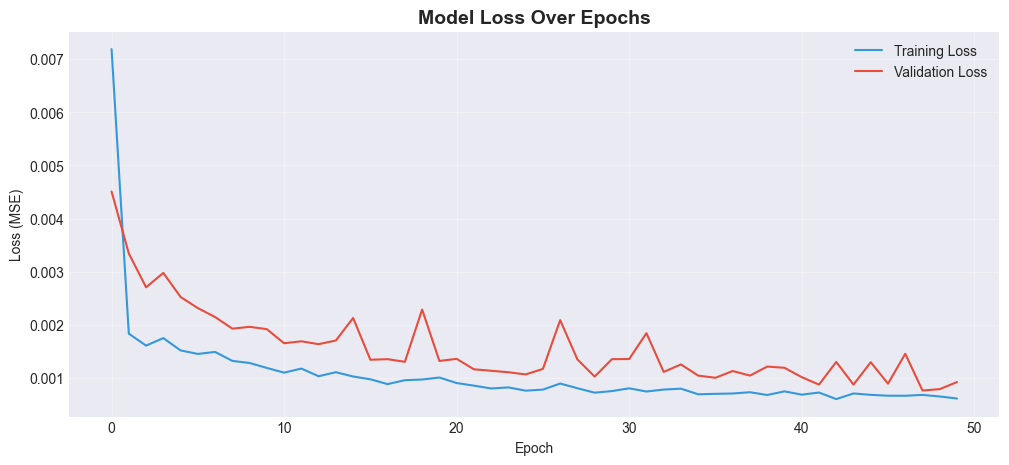

In [8]:
# Plot Training History
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss', color='#3498db')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c')
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

## 🔮 STEP 3: Forecasting and Evaluation

We predict on the technical test set (Jan 2025 - Jan 2026) and inverse transform to get dollar values.

In [9]:
# Generate Predictions
predictions_scaled = model.predict(X_test)

# Inverse Transform (scaled -> original price)
predictions = scaler.inverse_transform(predictions_scaled)
actuals = scaler.inverse_transform(y_test.reshape(-1, 1))

# Create Comparison DataFrame
# Note: y_test corresponds to the target value, which is the day AFTER the sequence
# We need to align with dates. The test_series_extended includes lookback.
# Example: if test starts Jan 1, sequence uses prev 60 days. Target is Jan 1 price.
test_dates = test_series_extended.index[LOOK_BACK:]

results_df = pd.DataFrame({
    'Date': test_dates,
    'Actual': actuals.flatten(),
    'Forecast': predictions.flatten()
})
results_df.set_index('Date', inplace=True)

print("="*50)
print("FORECAST SAMPLE")
print("="*50)
print(results_df.head())
print(f"\nTest Dates: {results_df.index.min().date()} to {results_df.index.max().date()}")

1/9 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step

8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


FORECAST SAMPLE
                Actual    Forecast
Date                              
2024-12-26  454.130005  431.662781
2024-12-27  431.660004  441.844940
2024-12-30  417.410004  437.788116
2024-12-31  403.839996  425.427368
2025-01-02  379.279999  409.920502

Test Dates: 2024-12-26 to 2026-01-15


In [10]:
# Calculate Evaluation Metrics
mae = mean_absolute_error(results_df['Actual'], results_df['Forecast'])
rmse = np.sqrt(mean_squared_error(results_df['Actual'], results_df['Forecast']))
mape = np.mean(np.abs((results_df['Actual'] - results_df['Forecast']) / results_df['Actual'])) * 100

# Create metrics table
metrics_lstm = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'Value': [f"${mae:.2f}", f"${rmse:.2f}", f"{mape:.2f}%"],
    'Description': [
        'Mean Absolute Error',
        'Root Mean Squared Error',
        'Mean Absolute Percentage Error'
    ]
})

print("="*50)
print("LSTM PERFORMANCE METRICS")
print("="*50)
print(metrics_lstm.to_string(index=False))

print(f"\nForecast Bias: ${(results_df['Forecast'].mean() - results_df['Actual'].mean()):.2f}")

LSTM PERFORMANCE METRICS
Metric  Value                    Description
   MAE $11.85            Mean Absolute Error
  RMSE $15.15        Root Mean Squared Error
  MAPE  3.49% Mean Absolute Percentage Error

Forecast Bias: $-1.53


---

## 📉 STEP 4: Visualization

Detailed visualization of model performance.

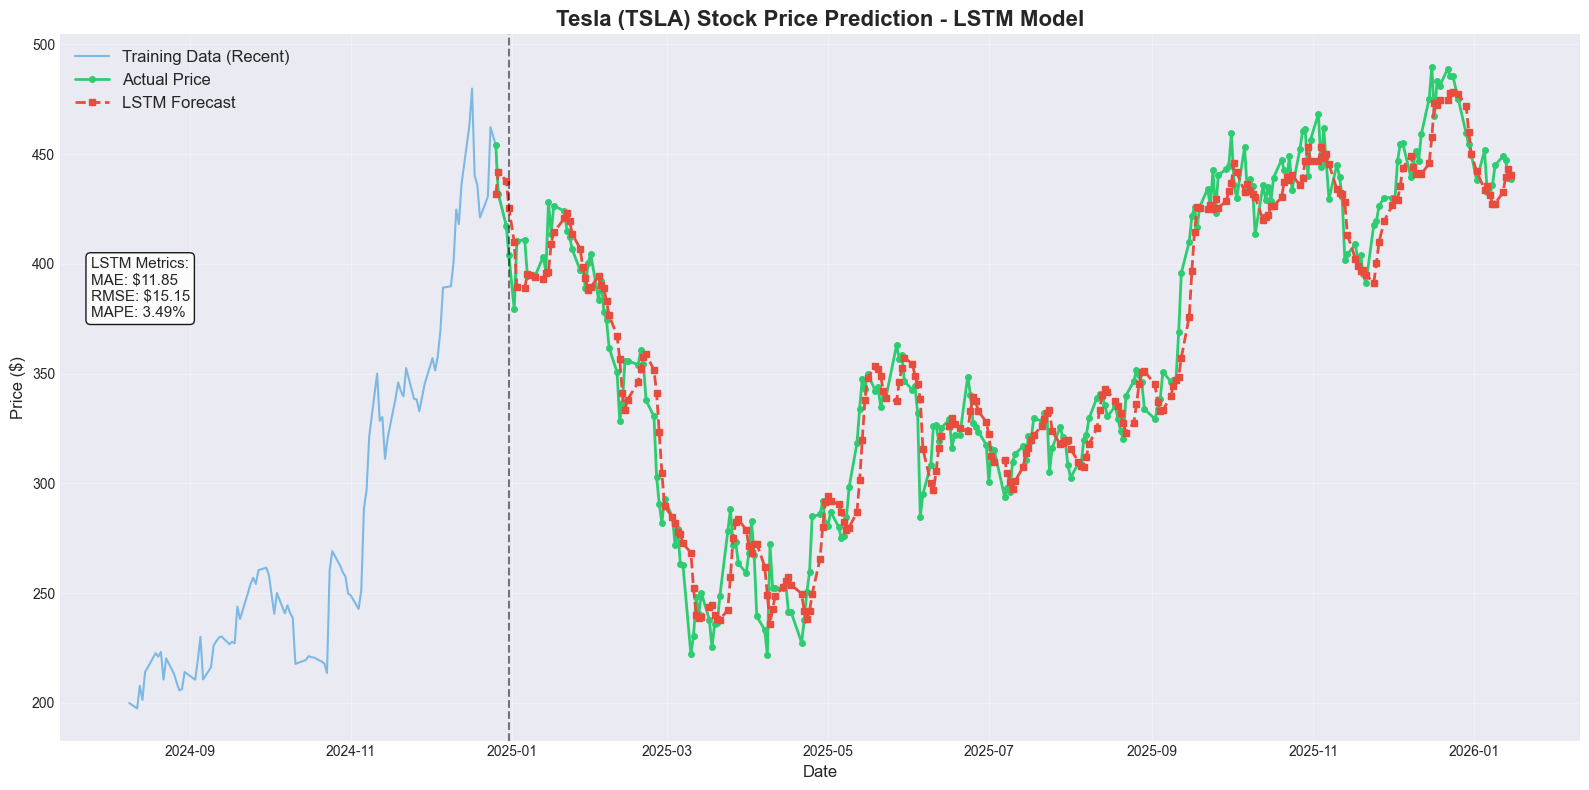

In [11]:
# Main Forecast Plot
plt.figure(figsize=(16, 8))

# Plot recent training data for context (last 100 days)
plt.plot(train_series.index[-100:], train_series.values[-100:], 
         label='Training Data (Recent)', color='#3498db', alpha=0.6)

# Plot Actual Test Data
plt.plot(results_df.index, results_df['Actual'], 
         label='Actual Price', color='#2ecc71', linewidth=2, marker='o', markersize=4)

# Plot Forecasts
plt.plot(results_df.index, results_df['Forecast'], 
         label='LSTM Forecast', color='#e74c3c', linewidth=2, linestyle='--', marker='s', markersize=4)

# Formatting
plt.title('Tesla (TSLA) Stock Price Prediction - LSTM Model', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
# Fix: Convert train_end string to timestamp for matplotlib
plt.axvline(x=pd.Timestamp(train_end), color='black', linestyle='--', alpha=0.5, label='Train/Test Split')

# Add metrics box
metrics_text = f'LSTM Metrics:\nMAE: ${mae:.2f}\nRMSE: ${rmse:.2f}\nMAPE: {mape:.2f}%'
plt.text(0.02, 0.60, metrics_text, transform=plt.gca().transAxes, 
         fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

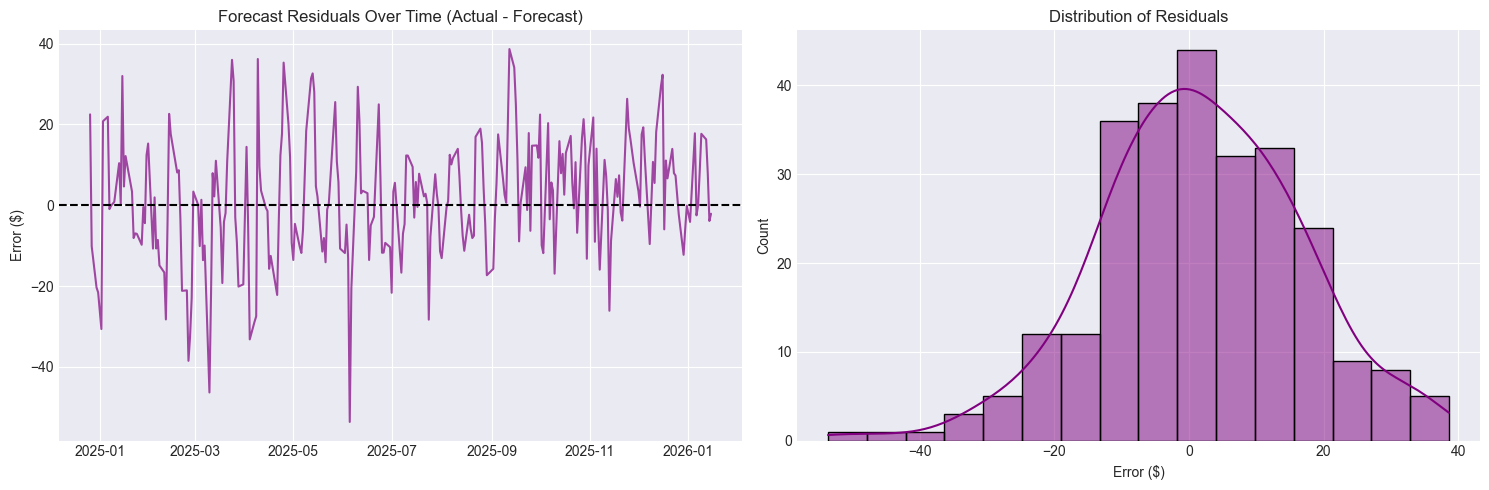

In [12]:
# Feature: Residual Analysis
residuals = results_df['Actual'] - results_df['Forecast']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residuals over time
axes[0].plot(results_df.index, residuals, color='purple', alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Forecast Residuals Over Time (Actual - Forecast)')
axes[0].set_ylabel('Error ($)')

# Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Error ($)')

plt.tight_layout()
plt.show()

---

## 📝 Discussion and Comparison

### LSTM vs. ARIMA

Neural networks (LSTM) and statistical models (ARIMA) approach forecasting differently:

1.  **Complexity:** LSTM can capture non-linear complex patterns, while ARIMA assumes linear relationships.
2.  **Context:** LSTM uses a long "lookback" window (60 days) to find patterns, essentially "remembering" recent history.
3.  **Data:** LSTMs require scaled data and large training sets. ARIMA works with raw (stationarized) data and is robust on smaller datasets.

### Limitations

-   **Lag Effect:** Like many time series models, LSTMs often act as a "moving average," potentially lagging behind sharp sudden price changes.
-   **Black Box:** Harder to interpret *why* a prediction was made compared to ARIMA coefficients.
-   **Overfitting:** Neural networks can easily overfit noise in financial data. We visualized the loss and used EarlyStopping to mitigate this.

### Conclusion
This LSTM model provides a powerful alternative to statistical forecasting. By combining both insights (ARIMA's trend/seasonality + LSTM's non-linearity), a portfolio manager can make more robust decisions.